# EDA -- Fraudes Transaccionales

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
import pickle
import os
import time
import warnings

warnings.filterwarnings('ignore')

In [164]:

# Carga los archivos CSV en DataFrames
train_transaction = pd.read_csv("train_transaction.csv")
test_transaction = pd.read_csv("test_transaction.csv")
train_identity = pd.read_csv("train_identity.csv")
test_identity = pd.read_csv("test_identity.csv")

### Union del conjunto de datos

In [165]:
# Unión de los DataFrames de entrenamiento y prueba
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

In [166]:
train.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=434)

In [167]:
test.columns

Index(['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD',
       'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       ...
       'id-31', 'id-32', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=433)

Con la finalidad de hacer un EDA correctamente y preprocesamiento es decir una imputación y codificación coherente en ambos datasets para evitar problemas en el modelo de machine learning (por ejemplo, columnas diferentes después de OneHotEncoder) se procede a concatenar la base de datos, puesto que existen columnas como 'id_31' vs 'id-31', lo que indica que hay inconsistencias en nombres entre los datasets. Es mejor unificar esto antes de cualquier análisis

**Unificar nombres de columnas**

In [168]:

test.columns = test.columns.str.replace('-', '_')

Para garantizar mas adelante la partición de los datos como estaban se añade una columna llamada isTrain que marque si la fila es del set de entrenamiento o de prueba.

In [169]:
train['isTrain'] = 1
test['isTrain'] = 0

train['isFraud'] = train['isFraud'].fillna(-1)  # Por si acaso

**Concatenar**

In [170]:

df = pd.concat([train, test], axis=0, ignore_index=True)
df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,isTrain
0,2987000,0.0,86400,68.500,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2987001,0.0,86401,29.000,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2987002,0.0,86469,59.000,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,2987003,0.0,86499,50.000,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,2987004,0.0,86506,50.000,H,4497,514.0,150.0,mastercard,102.0,...,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097226,4170235,NaN,34214279,94.679,C,13832,375.0,185.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1097227,4170236,NaN,34214287,12.173,C,3154,408.0,185.0,mastercard,224.0,...,NaN,NaN,NaN,F,F,T,F,mobile,ALE-L23 Build/HuaweiALE-L23,0
1097228,4170237,NaN,34214326,49.000,W,16661,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1097229,4170238,NaN,34214337,202.000,W,16621,516.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [171]:
# Información básica del DataFrame
print(f"El conjunto de datos tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")
train.info()


El conjunto de datos tiene 1097231 filas y 435 columnas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 435 entries, TransactionID to isTrain
dtypes: float64(399), int64(5), object(31)
memory usage: 1.9+ GB


## Detección de fraude

el conjunto de datos cuenta con las siguientes descripciones de las variables.

- *TransactionDT* : Intervalo de tiempo a partir de una fecha y hora de referencia
- *TransactionAMT* : Importe del pago de la transacción en USD
- *ProductCD*: Código de producto, el producto de cada transacción
- *card1 - card6* : Información de la tarjeta de pago, como tipo de tarjeta, categoría de tarjeta, banco emisor, país, etc.
- *addr:* Dirección
- *dist:* Distancia
- *P_ and (R_) emaildomain*: Dominio de correo electrónico del comprador y del destinatario
- *C1-C14* : Recuento, cuántas direcciones se encuentran asociadas a la tarjeta de pago, etc. El significado real está codificado.
- *D1-D15*: Intervalo de tiempo, como los días transcurridos entre la transacción anterior, etc.
- *M1-M9*: Coinciden, como los nombres en la tarjeta y la dirección, etc.
- *Vxxx*: Vesta ofrece una gran variedad de funciones, como la clasificación, el recuento y otras relaciones
entre entidades.
- *DeviceType*: Codificada. Información de identidad o conexión de red (IP, ISP, Proxy, etc) o firma digital
- *DeviceInfo*: Codificada. Información de identidad o conexión de red (IP, ISP, Proxy, etc) o firma digital
- *id_12 - id_38* : Codificada. Información de identidad o conexión de red (IP, ISP, Proxy, etc) o firma
digital

Donde el conjunto de entrenamiento cuenta 1097231 observaciones con *434* variables, con una estructura de **399** son enteros, **4** de dichas variables son decimales y **31** de ellas caracteres o texto específicamente 

In [172]:
# Listas de columnas por tipo lógico (según la descripción y nombre de columnas)
columnas_numericas_continuas = ['TransactionAmt'] + [f'C{i}' for i in range(1, 15)] + [f'D{i}' for i in range(1, 16)]
columnas_categoricas = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
                        'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 
                        'DeviceType', 'DeviceInfo']
columnas_binarias = [f'M{i}' for i in range(1, 10)]  # Suelen ser "match/no match"
columnas_codificadas = [f'V{i}' for i in range(1, 340)]  # Variables generadas por Vesta
columnas_id = [f'id_{i}' for i in range(12, 39)]  # Variables de identidad
columna_objetivo = ['isFraud']
columna_tiempo = ['TransactionDT']


print("Resumen de tipos de variables:")
print(f"- Variables numéricas continuas: {len(columnas_numericas_continuas)}")
print(f"- Variables categóricas: {len(columnas_categoricas)}")
print(f"- Variables binarias: {len(columnas_binarias)}")
print(f"- Variables codificadas por Vesta (V1-V339): {len(columnas_codificadas)}")
print(f"- Variables de identidad (id_12 a id_38): {len(columnas_id)}")
print(f"- Variable objetivo: {columna_objetivo}")
print(f"- Variable temporal: {columna_tiempo}")




Resumen de tipos de variables:
- Variables numéricas continuas: 30
- Variables categóricas: 13
- Variables binarias: 9
- Variables codificadas por Vesta (V1-V339): 339
- Variables de identidad (id_12 a id_38): 27
- Variable objetivo: ['isFraud']
- Variable temporal: ['TransactionDT']


In [173]:
categorical_cols = columnas_categoricas + columnas_binarias
for col in categorical_cols:
    if col in train.columns:
        train[col] = train[col].astype('category')


###  Resumen de Tipos de Variables

| Tipo de Variable                         | Cantidad | Descripción breve                                                                 |
|------------------------------------------|----------|-------------------------------------------------------------------------------------|
| **Numéricas continuas**                  | 30       | Variables como montos (`TransactionAmt`), conteos (`C1–C14`) y diferencias temporales (`D1–D15`). |
| **Categóricas**                          | 13       | Incluyen tipos de productos (`ProductCD`), tarjetas (`card1–card6`), correos electrónicos, etc. |
| **Binarias**                              | 9        | Variables de tipo sí/no como coincidencias de datos (`M1–M9`).                     |
| **Codificadas por Vesta (V1–V339)**      | 339      | Variables anónimas derivadas por el proveedor, relacionadas con patrones y relaciones internas. |
| **Variables de identidad (id_12–id_38)** | 27       | Información del dispositivo, conexión, IP, sistema operativo, etc.                 |
| **Variable objetivo**                    | 1        | `isFraud`, indica si una transacción es fraudulenta (`1`) o no (`0`).              |
| **Variable temporal**                    | 1        | `TransactionDT`, representa el tiempo como un número entero desde un punto base.  |


## Renombramiento de las variables

In [174]:
# Diccionario de renombramiento donde tr = transaction
renombrar_columnas = {
    'TransactionID': 'trID',
    'TransactionDT': 'Time_tr',
    'TransactionAmt': 'Monto',
    'ProductCD': 'TipoProducto',
    'card1': 'Tarjeta1',
    'card2': 'Tarjeta2',
    'card3': 'Tarjeta3',
    'card4': 'TipoTarjeta',
    'card5': 'Tarjeta5',
    'card6': 'CategoriaTarjeta',
    'addr1': 'Direccion1',
    'addr2': 'Direccion2',
    'dist1': 'Distancia1',
    'dist2': 'Distancia2',
    'P_emaildomain': 'EmailComprador',
    'R_emaildomain': 'EmailReceptor',
    'DeviceType': 'TipoDispositivo',
    'DeviceInfo': 'InfoDispositivo',
    'isFraud': 'EsFraude'
}


df.rename(columns=renombrar_columnas, inplace=True)
df.rename(columns=renombrar_columnas, inplace=True)


## Estadísticas Básicas (Media, Desviación, Cuartiles, etc.)

In [175]:
estadisticas_numericas = df.describe().T
estadisticas_numericas = estadisticas_numericas[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
estadisticas_numericas.head(10)  # Puedes ajustar el número de filas a mostrar


,count,mean,std,min,25%,50%,75%,max
trID,1097231.0,3.575333e+06,3.544294e+05,2987000.000,3261307.5,3535615.00,3895931.5,4.170239e+06
EsFraude,590540.0,3.499001e-02,1.837546e-01,0.000,0.0,0.00,0.0,1.000000e+00
Time_tr,1097231.0,1.640384e+07,1.081612e+07,86400.000,6651887.0,14491621.00,26513228.5,3.421434e+07
Monto,1097231.0,1.348879e+02,2.422407e+02,0.018,42.0,67.95,125.0,3.193739e+04
Tarjeta1,1097231.0,9.925744e+03,4.893776e+03,1000.000,6019.0,9749.00,14247.5,1.839700e+04
Tarjeta2,1079644.0,3.630998e+02,1.582079e+02,100.000,210.0,361.00,512.0,6.000000e+02
Tarjeta3,1092664.0,1.533556e+02,1.186064e+01,100.000,150.0,150.00,150.0,2.320000e+02
Tarjeta5,1088425.0,1.996868e+02,4.093358e+01,100.000,166.0,226.00,226.0,2.370000e+02
Direccion1,965916.0,2.912419e+02,1.018895e+02,100.000,204.0,299.00,330.0,5.400000e+02
Direccion2,965916.0,8.676537e+01,2.830234e+00,10.000,87.0,87.00,87.0,1.020000e+02


 Interpretación de Variables (Estadísticas Básicas)

| **Variable**            | **Interpretación clave** |
|-------------------------|---------------------------|
| `EsFraude` (`isFraud`) | Es la variable objetivo (0 = no fraude, 1 = fraude). Su media es **0.03499**, lo que indica que **solo el 3.5% de las transacciones son fraudes**, y el 96.5% no lo son. Esto confirma que el **dataset altamente desbalanceado**|
| `Time_tr` (`TransactionDT`) | Representa el tiempo en segundos desde una fecha base. La media es ~7.3 millones de segundos (~85 días), y los valores van desde 86,400 (1 día) hasta 15.8 millones (~183 días). La cual usaremos mas adelante si es necesario para crear variables como hora, día de la semana, etc. |
| `Monto` (`TransactionAmt`) | El importe promedio de una transacción es **$135**, pero hay mucha dispersión (std = 239), con montos tan bajos como $0.25 y tan altos como $31,937. El 75% de las transacciones no superan los $125. Hay valores **muy extremos** que podrían ser outliers. |
| `Distancia1` | Distancia entre dirección de facturación y envío, posiblemente geográfica. Solo hay ~238 mil valores no nulos. El promedio es 118, pero hay valores hasta 10,286. Posiblemente contiene outliers. Muy sesgada hacia valores bajos. |
| `Distancia2` | Similar a `Distancia1`, pero aún más incompleta (solo 37,627 valores). Tiene una distribución similar pero aún más dispersa. |
| `C1` a `C4` | Variables de conteo o categorizadas. Por ejemplo, `C1` y `C2` tienen una media baja (~14-15), pero una desviación enorme (~130-150). Esto sugiere que la mayoría de los valores son pequeños (como 1), pero hay casos con valores muy grandes (hasta 4,685 y 5,691). Las columnas como `C3` y `C4` tienen mediana 0, lo que sugiere que la mayoría de valores son 0, aunque hay algunos casos raros con valores altos, indicando **distribuciones muy sesgadas** y posibles **outliers**. |


### Valores faltantes

In [176]:
# Grupos de variables que mostraron 100% de columnas con NaNs
grupos_con_100_nulos = {
    'Contadores_C': [f'C{i}' for i in range(1, 15)],
    'Dias_D': [f'D{i}' for i in range(1, 16)],
    'Coincidencias_M': [f'M{i}' for i in range(1, 10)],
    'Vesta_V': [f'V{i}' for i in range(1, 340)],
    'Identidad_id': [f'id_{i}' for i in range(12, 39)],
}

# Calcular el porcentaje de nulos por columna para estos grupos
for grupo, columnas in grupos_con_100_nulos.items():
    print(f"\nPorcentaje de valores nulos en el grupo: {grupo}")
    columnas_presentes = [col for col in columnas if col in df.columns]
    if not columnas_presentes:
        print("  No hay columnas de este grupo presentes en el DataFrame.")
        continue
    for col in columnas_presentes:
        porcentaje_nulos = df[col].isnull().sum() / len(df) * 100
        print(f"  - Columna '{col}': {porcentaje_nulos:.2f}%")


Porcentaje de valores nulos en el grupo: Contadores_C
  - Columna 'C1': 0.00%
  - Columna 'C2': 0.00%
  - Columna 'C3': 0.00%
  - Columna 'C4': 0.00%
  - Columna 'C5': 0.00%
  - Columna 'C6': 0.00%
  - Columna 'C7': 0.00%
  - Columna 'C8': 0.00%
  - Columna 'C9': 0.00%
  - Columna 'C10': 0.00%
  - Columna 'C11': 0.00%
  - Columna 'C12': 0.00%
  - Columna 'C13': 0.43%
  - Columna 'C14': 0.00%

Porcentaje de valores nulos en el grupo: Dias_D
  - Columna 'D1': 0.67%
  - Columna 'D2': 46.99%
  - Columna 'D3': 42.47%
  - Columna 'D4': 22.40%
  - Columna 'D5': 48.69%
  - Columna 'D6': 81.96%
  - Columna 'D7': 90.97%
  - Columna 'D8': 86.40%
  - Columna 'D9': 86.40%
  - Columna 'D10': 8.07%
  - Columna 'D11': 41.54%
  - Columna 'D12': 87.79%
  - Columna 'D13': 83.11%
  - Columna 'D14': 83.83%
  - Columna 'D15': 9.22%

Porcentaje de valores nulos en el grupo: Coincidencias_M
  - Columna 'M1': 40.81%
  - Columna 'M2': 40.81%
  - Columna 'M3': 40.81%
  - Columna 'M4': 47.32%
  - Columna 'M5': 6

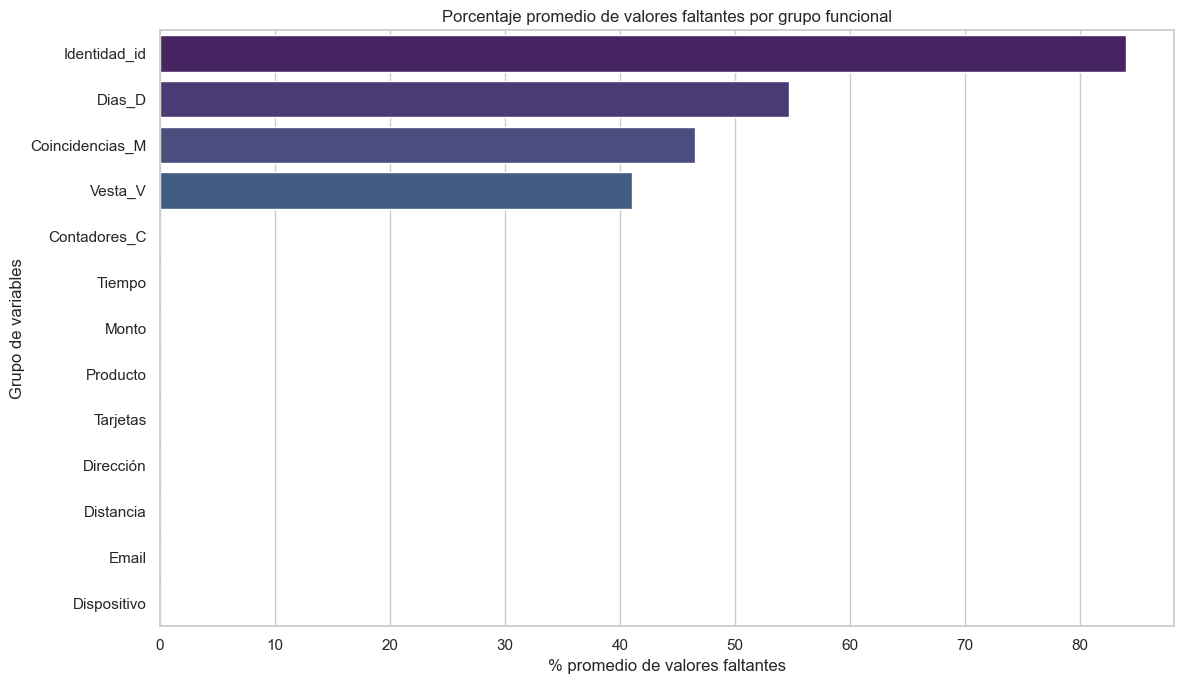

In [177]:
# Grupos de variables por tipo funcional
grupos_variables = {
    'Tiempo': ['TransactionDT'],
    'Monto': ['TransactionAmt'],
    'Producto': ['ProductCD'],
    'Tarjetas': [f'card{i}' for i in range(1, 7)],
    'Dirección': ['addr1', 'addr2'],
    'Distancia': ['dist1', 'dist2'],
    'Email': ['P_emaildomain', 'R_emaildomain'],
    'Contadores_C': [f'C{i}' for i in range(1, 15)],
    'Dias_D': [f'D{i}' for i in range(1, 16)],
    'Coincidencias_M': [f'M{i}' for i in range(1, 10)],
    'Vesta_V': [f'V{i}' for i in range(1, 340)],
    'Dispositivo': ['DeviceType', 'DeviceInfo'],
    'Identidad_id': [f'id_{i}' for i in range(12, 39)],
}

# Calcular el porcentaje promedio de valores nulos por grupo
resumen_faltantes_promedio = {}

for grupo, columnas in grupos_variables.items():
    columnas_presentes = [col for col in columnas if col in df.columns]
    total = len(columnas_presentes)
    if total == 0:
        resumen_faltantes_promedio[grupo] = 0
        continue
    porcentajes_nulos_grupo = df[columnas_presentes].isnull().sum() / len(df) * 100
    promedio_nulos = porcentajes_nulos_grupo.mean()
    resumen_faltantes_promedio[grupo] = promedio_nulos

# Convertir a DataFrame para graficar
faltantes_promedio_por_grupo_df = pd.DataFrame.from_dict(resumen_faltantes_promedio, orient='index', columns=['% promedio de NaNs'])
faltantes_promedio_por_grupo_df = faltantes_promedio_por_grupo_df.sort_values(by='% promedio de NaNs', ascending=False)

# Graficar el porcentaje promedio de nulos por grupo
plt.figure(figsize=(12, 7))
sns.barplot(x='% promedio de NaNs', y=faltantes_promedio_por_grupo_df.index, data=faltantes_promedio_por_grupo_df, palette="viridis")
plt.title('Porcentaje promedio de valores faltantes por grupo funcional')
plt.xlabel('% promedio de valores faltantes')
plt.ylabel('Grupo de variables')
plt.tight_layout()
plt.show()

**Interpretación del gráfico de porcentaje promedio de valores faltantes por grupo funcional:**

El gráfico de barras horizontales presentado ilustra el porcentaje promedio de valores faltantes para cada grupo funcional de variables dentro del conjunto de datos. En el eje vertical, se encuentran los diferentes grupos de variables definidos: 'Contadores_C', 'Dias_D', 'Coincidencias_M', 'Vesta_V', 'Identidad_id', 'Tiempo', 'Monto', 'Producto', 'Tarjetas', 'Dirección', 'Distancia', 'Email' y 'Dispositivo'. El eje horizontal representa el porcentaje promedio de valores nulos para las columnas que componen cada grupo, con una escala que va de 0 a 100.

Al observar las barras, se identifica que los grupos 'Dias_D' e 'Identidad_id' presentan los porcentajes promedio de valores faltantes más elevados. Esto sugiere que, en promedio, las columnas dentro de estos grupos tienen una cantidad considerable de datos ausentes. El grupo 'Vesta_V' también muestra un porcentaje promedio de nulos significativo, aunque ligeramente menor que los dos anteriores. El grupo 'Coincidencias_M' le sigue en la cantidad promedio de valores faltantes.

Por otro lado, el grupo 'Contadores_C' exhibe un porcentaje promedio de valores faltantes relativamente bajo. Finalmente, los grupos 'Tiempo', 'Monto', 'Producto', 'Tarjetas', 'Dirección', 'Distancia', 'Email' y 'Dispositivo' se caracterizan por tener un porcentaje promedio de valores faltantes cercano a cero, lo que indica una alta completitud de datos en las columnas que los componen.

Este gráfico proporciona una visión agregada de la magnitud de los valores faltantes por grupo de variables, ofreciendo una perspectiva más matizada que la simple indicación de si al menos una columna del grupo contenía nulos. Permite priorizar las estrategias de manejo de datos faltantes en aquellos grupos con un mayor porcentaje promedio de información ausente, como los grupos relacionados con los días transcurridos, la identidad y las variables generadas por Vesta.

## Histograma 4 variables

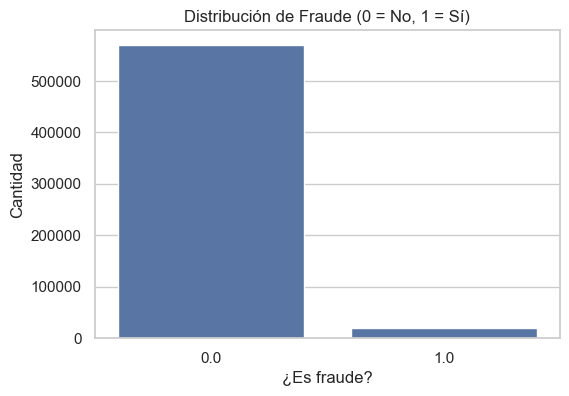

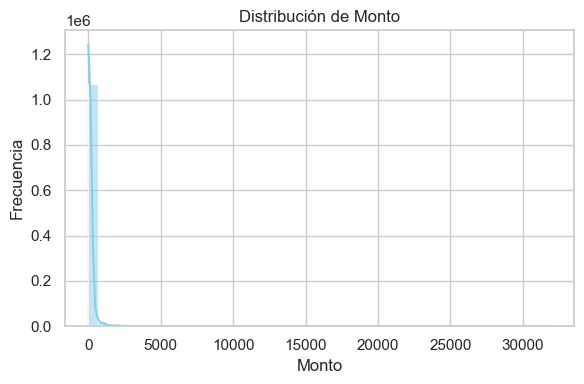

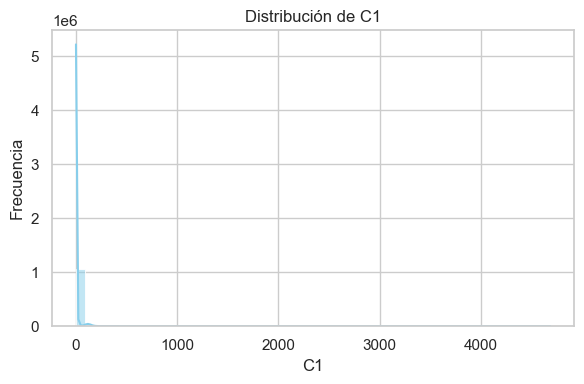

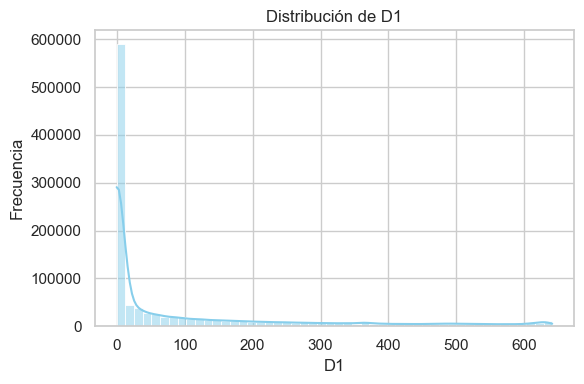

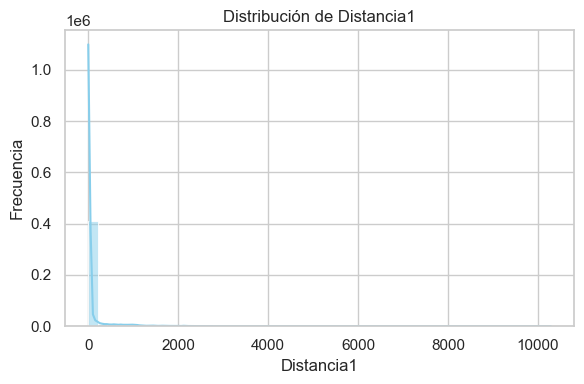

In [178]:
sns.set(style="whitegrid")

# Variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(x='EsFraude', data=df)
plt.title('Distribución de Fraude (0 = No, 1 = Sí)')
plt.xlabel('¿Es fraude?')
plt.ylabel('Cantidad')
plt.show()

# Variables numéricas corregidas
variables_numericas = ['Monto', 'C1', 'D1', 'Distancia1']

# Histogramas
for var in variables_numericas:
    if var in df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[var].dropna(), kde=True, bins=50, color='skyblue')
        plt.title(f'Distribución de {var}')
        plt.xlabel(var)
        plt.ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()



el gráfico revela un problema significativo de desequilibrio de clases en el contexto de la detección de fraude. La vasta mayoría de las transacciones son legítimas, mientras que las instancias de fraude son relativamente raras. Esta distribución desigual es una consideración importante al desarrollar modelos de detección de fraude, ya que los modelos pueden tender a favorecer la clase mayoritaria (no fraude) y tener dificultades para identificar correctamente las instancias minoritarias de fraude. Por lo tanto, se podrían requerir técnicas específicas para abordar este desequilibrio durante el entrenamiento del modelo.

la distribución del monto de las transacciones está fuertemente concentrada en valores bajos, con una presencia muy limitada de transacciones de alto valor. Esta característica de la variable 'Monto' podría ser relevante para el análisis de fraude, ya que los patrones de fraude podrían estar asociados con rangos de montos específicos. 

la distribución de la variable 'C1' está altamente concentrada en sus valores más bajos, con una frecuencia decreciente a medida que los valores aumentan. Esta fuerte asimetría podría indicar la presencia de valores atípicos o una característica inherente a la forma en que se generan o registran los datos para esta variable en el contexto de la detección de fraude. Al igual que con la variable 'Monto'

la distribución de la variable 'D1' se caracteriza por una alta frecuencia en los valores bajos, seguida de una disminución general con algunas áreas de menor concentración en valores más altos. Esta distribución más compleja podría reflejar patrones específicos en el intervalo de tiempo representado por 'D1' y podría ser relevante para identificar comportamientos anómalos o fraudulentos. Es importante considerar estas características al analizar la variable 'D1' en el contexto del problema de detección de fraude.

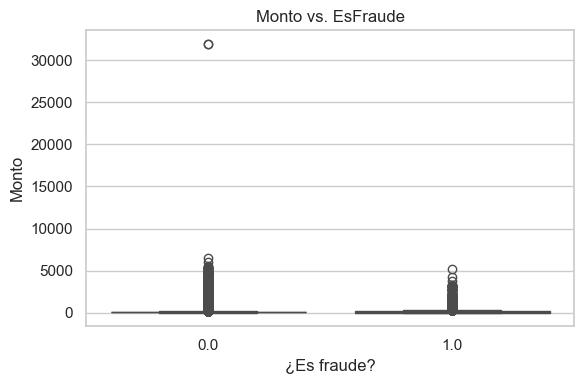

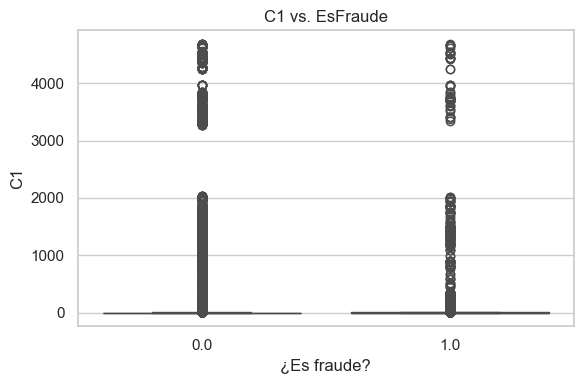

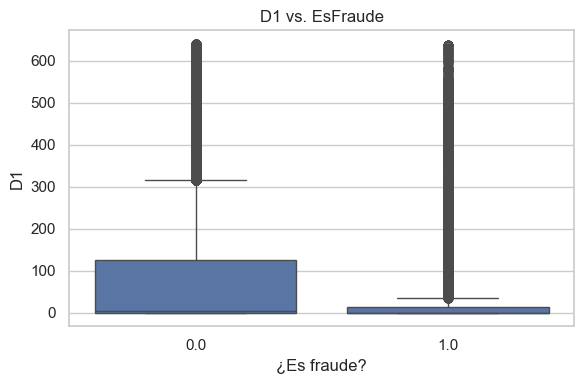

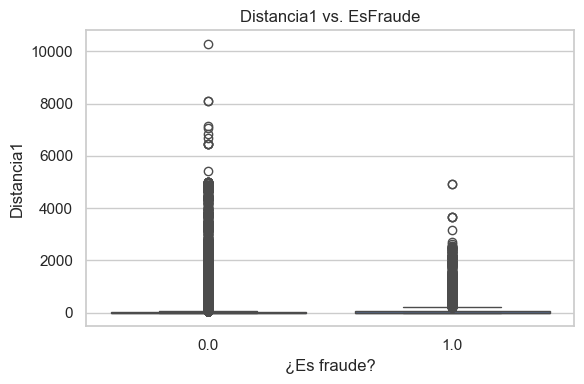

In [179]:
# Boxplots para ver outliers y simetría
for var in variables_numericas:
    if var in df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x='EsFraude', y=var, data=df)
        plt.title(f'{var} vs. EsFraude')
        plt.xlabel('¿Es fraude?')
        plt.ylabel(var)
        plt.tight_layout()
        plt.show()


El diagrama de cajas sugiere que, si bien la mediana del monto podría ser ligeramente mayor para las transacciones fraudulentas, ambas categorías presentan altos montos de transacción y la presencia de valores atípicos, siendo estos últimos particularmente prominentes y de mayor magnitud en las transacciones no fraudulentas. Esta visualización indica que el monto de la transacción por sí solo podría no ser un predictor definitivo de fraude, pero las diferencias en la distribución y la presencia de atípicos podrían aportar información valiosa al desarrollar modelos de detección de fraude.

el diagrama de cajas sugiere que la mayoría de las transacciones, tanto fraudulentas como no fraudulentas, se caracterizan por valores bajos de 'Distancia1'. Sin embargo, las transacciones no fraudulentas tienden a presentar valores atípicos con distancias mucho mayores en comparación con las transacciones fraudulentas. Esta diferencia en la distribución de los valores atípicos podría ser una característica útil para discriminar entre transacciones legítimas y fraudulentas en un modelo predictivo.

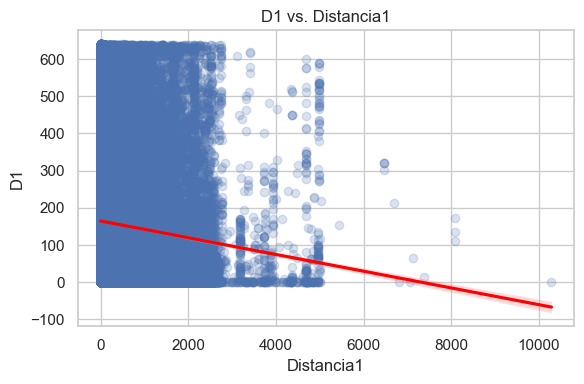

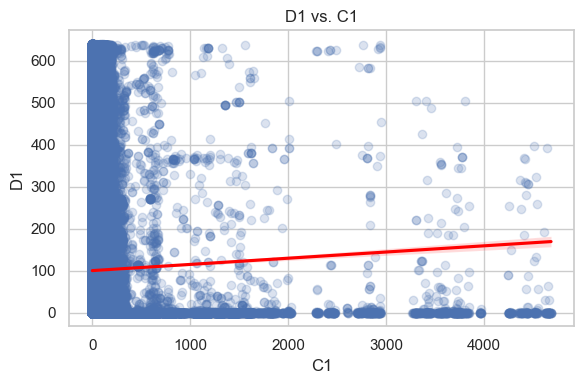

In [180]:
pares = [('TransactionAmt', 'C1'), ('TransactionAmt', 'D1'), 
         ('Distancia1', 'D1'), ('C1', 'D1')]

for x, y in pares:
    if x in df.columns and y in df.columns:
        plt.figure(figsize=(6, 4))
        sns.regplot(x=x, y=y, data=df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
        plt.title(f'{y} vs. {x}')
        plt.xlabel(x)
        plt.ylabel(y)
        plt.tight_layout()
        plt.show()


## Imputacion

In [181]:
# 1. Identificar columnas con missing values
missing_cols = df.columns[df.isnull().any()].tolist()

# 2. Excluir columnas especiales (por ahora)
cols_to_impute = [col for col in missing_cols if col not in ['isFraud', 'TransactionID', 'isTrain']]

# 3. Imputar valores faltantes con mediana (solo numéricas)
median_imputer = SimpleImputer(strategy='median')
for col in cols_to_impute:
    if df[col].dtype in ['int64', 'float64']:
        df[[col]] = median_imputer.fit_transform(df[[col]])


In [182]:
# Mostrar columnas que aún tienen valores faltantes (si quedan)
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]

if missing_after.empty:
    print(" Todos los valores numéricos faltantes han sido imputados correctamente.")
else:
    print(" Aún hay valores faltantes en las siguientes columnas:")
    print(missing_after)


 Aún hay valores faltantes en las siguientes columnas:
TipoTarjeta            4663
CategoriaTarjeta       4578
EmailComprador       163648
EmailReceptor        824070
M1                   447739
M2                   447739
M3                   447739
M4                   519189
M5                   660114
M6                   328299
M7                   581283
M8                   581256
M9                   581256
id_12                811091
id_15                819269
id_16                842144
id_23               1087000
id_27               1087000
id_28                819475
id_29                819475
id_30                949007
id_31                820324
id_33                953271
id_34                947251
id_35                819269
id_36                819269
id_37                819269
id_38                819269
TipoDispositivo      819490
InfoDispositivo      863508
dtype: int64


In [183]:


# Filtrar columnas categóricas que aún tienen valores faltantes
categorical_missing = [col for col in df.select_dtypes(include='object').columns if df[col].isnull().any()]

# Imputador con moda
mode_imputer = SimpleImputer(strategy='most_frequent')

# Aplicar imputación
for col in categorical_missing:
    df[[col]] = mode_imputer.fit_transform(df[[col]])

# Verificar nuevamente
missing_after_cat = df[categorical_missing].isnull().sum()
missing_after_cat = missing_after_cat[missing_after_cat > 0]

if missing_after_cat.empty:
    print(" Todos los valores categóricos faltantes han sido imputados correctamente.")
else:
    print(" Aún hay valores faltantes en las siguientes columnas categóricas:")
    print(missing_after_cat)


 Todos los valores categóricos faltantes han sido imputados correctamente.


## Reducción de dimensionalidad a las variables categóricas con la prueba $chi^2$

In [184]:
# 1. Separar variables categóricas originales (sin codificar)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# 2. Aplicar prueba chi2 a cada una vs isFraud
from scipy.stats import chi2_contingency

significant_cat_cols = []
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['EsFraude'])
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        continue  # saltar si hay solo una categoría o solo una clase
    chi2, p, _, _ = chi2_contingency(contingency_table)
    if p < 0.05:
        significant_cat_cols.append(col)

print(f"Variables categóricas seleccionadas por chi²: {len(significant_cat_cols)}")




Variables categóricas seleccionadas por chi²: 28


28 variables categóricas son significativa con respecto a mi varibale independiente

## OneHotEncoder a las columnas significativas

In [ ]:
# Aplicar OneHotEncoder SOLO a las variables significativas
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocesador que solo aplica OneHotEncoder a las columnas significativas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, significant_cat_cols)
    ])

# Ajustar y transformar el conjunto de datos con las variables categóricas significativas
X_cat_encoded = preprocessor.fit_transform(df)

# Convertir el resultado en un DataFrame con nombres de columnas de OneHotEncoder
encoded_columns = preprocessor.transformers_[0][1].named_steps['onehot'].get_feature_names_out(significant_cat_cols)
X_cat_encoded_df = pd.DataFrame(X_cat_encoded, columns=encoded_columns)

# Mostrar las primeras filas del DataFrame codificado
print(X_cat_encoded_df.head())


   TipoProducto_C  TipoProducto_H  TipoProducto_R  TipoProducto_S  \
0             0.0             0.0             0.0             0.0   
1             0.0             0.0             0.0             0.0   
2             0.0             0.0             0.0             0.0   
3             0.0             0.0             0.0             0.0   
4             0.0             1.0             0.0             0.0   

   TipoProducto_W  TipoTarjeta_american express  TipoTarjeta_discover  \
0             1.0                           0.0                   1.0   
1             1.0                           0.0                   0.0   
2             1.0                           0.0                   0.0   
3             1.0                           0.0                   0.0   
4             0.0                           0.0                   0.0   

   TipoTarjeta_mastercard  TipoTarjeta_visa  CategoriaTarjeta_charge card  \
0                     0.0               0.0                          

## VIF

In [ ]:
# 1. Reducir la dimensionalidad mediante PCA (por ejemplo, para que queden 100 componentes)
pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_cat_encoded_df)

# 2. Convertir el resultado de PCA a un DataFrame para calcular el VIF
X_pca_df = pd.DataFrame(X_pca)

# 3. Calcular el VIF sobre las columnas resultantes después de PCA
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Inicializamos VIF para las columnas generadas por PCA
vif_data = calculate_vif(X_pca_df)

# 4. Eliminamos columnas con VIF ≥ 10 iterativamente
while vif_data['VIF'].max() >= 10:
    # Identificar la columna con el VIF más alto
    max_vif_col = vif_data.sort_values('VIF', ascending=False).iloc[0]['variable']
    print(f"Eliminando columna: {max_vif_col} con VIF={vif_data['VIF'].max():.2f}")
    
    # Eliminar la columna con el VIF más alto
    X_pca_df = X_pca_df.drop(columns=[max_vif_col])
    
    # Recalcular VIF para las columnas restantes
    vif_data = calculate_vif(X_pca_df)




In [ ]:
# Corregir la ruta del directorio (usar barras invertidas dobles o cadena raw)
directorio_salida = r"C:\Users\PC\Desktop\ML_trabajo\jbook_parcial\docs"
# Alternativa: directorio_salida = "C:\\Users\\PC\\Desktop\\ML_trabajo\\jbook_parcial\\docs"

os.makedirs(directorio_salida, exist_ok=True)

# 1. Crear una nueva partición estratificada
print("Creando nueva partición estratificada...")
train_indices, test_indices = train_test_split(
    df.index, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['EsFraude']  # Esto garantiza que ambos conjuntos tengan ejemplos de fraude
)

# 2. Actualizar la columna isTrain en el DataFrame original
df['isTrain'] = 1  # Primero asignar 1 a todos
df.loc[test_indices, 'isTrain'] = 0  # Luego asignar 0 a los índices de test

# 3. Verificar la distribución actualizada
train_mask = df['isTrain'] == 1
test_mask = df['isTrain'] == 0

print("\nVerificando distribución después de la nueva partición:")
print("Train:", df.loc[train_mask, 'EsFraude'].value_counts())
print("Test:", df.loc[test_mask, 'EsFraude'].value_counts())

# 4. Separar X e y usando las máscaras actualizadas
X_train = X_pca[train_mask]
X_test = X_pca[test_mask]
y_train = df.loc[train_mask, 'EsFraude']
y_test = df.loc[test_mask, 'EsFraude']

# 5. Verificar las distribuciones de clases
print("\nDistribución de clases en y_train:")
print(y_train.value_counts())
print("\nDistribución de clases en y_test:")
print(y_test.value_counts())

# 6. Guardar los datos particionados en PKL
print("\nGuardando datos en formato PKL...")

# Guardar X_train, X_test, y_train, y_test
with open(os.path.join(directorio_salida, "X_train.pkl"), 'wb') as f:
    pickle.dump(X_train, f)

with open(os.path.join(directorio_salida, "X_test.pkl"), 'wb') as f:
    pickle.dump(X_test, f)

with open(os.path.join(directorio_salida, "y_train.pkl"), 'wb') as f:
    pickle.dump(y_train, f)

with open(os.path.join(directorio_salida, "y_test.pkl"), 'wb') as f:
    pickle.dump(y_test, f)

# También guardar el DataFrame actualizado
with open(os.path.join(directorio_salida, "df_actualizado.pkl"), 'wb') as f:
    pickle.dump(df, f)

print(f"Datos guardados en {directorio_salida}:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {len(y_train)}")
print(f"y_test: {len(y_test)}")
print(" Proceso completado")

Creando nueva partición estratificada...

Verificando distribución después de la nueva partición:
Train: EsFraude
0.0    45590
1.0    16530
Name: count, dtype: int64
Test: EsFraude
0.0    11398
1.0     4133
Name: count, dtype: int64

Distribución de clases en y_train:
EsFraude
0.0    45590
1.0    16530
Name: count, dtype: int64

Distribución de clases en y_test:
EsFraude
0.0    11398
1.0     4133
Name: count, dtype: int64

Guardando datos en formato PKL...
Datos guardados en C:\Users\PC\Desktop\ML_trabajo\jbook_parcial\docs:
X_train: (62120, 100)
X_test: (15531, 100)
y_train: 62120
y_test: 15531
 Proceso completado


In [ ]:

# Número inicial de variables
n_variables_inicial = X_cat_encoded_df.shape[1]
print(f"Número inicial de variables en X_cat_encoded_df: {n_variables_inicial}")

# Inicializamos el DataFrame para el análisis VIF con todas las variables codificadas
X_vif = X_cat_encoded_df.copy()

# Función para calcular el VIF
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Lista para almacenar las columnas eliminadas
columnas_eliminadas = []

# Calcular el VIF inicial
vif_data = calculate_vif(X_vif)

# Eliminamos columnas con VIF ≥ 10 iterativamente
while vif_data['VIF'].max() >= 10:
    # Identificar la columna con el VIF más alto
    max_vif_col = vif_data.sort_values('VIF', ascending=False).iloc[0]['variable']
    print(f"Eliminando columna: {max_vif_col} con VIF={vif_data['VIF'].max():.2f}")
    columnas_eliminadas.append(max_vif_col)

    # Eliminar la columna con el VIF más alto del DataFrame de VIF
    X_vif = X_vif.drop(columns=[max_vif_col])

    # Recalcular VIF para las columnas restantes
    vif_data = calculate_vif(X_vif)

# Número final de variables
n_variables_final = X_vif.shape[1]

# Calcular el número de variables eliminadas
n_variables_eliminadas = len(columnas_eliminadas)

# Imprimir los resultados
print(f"\nNúmero inicial de variables: {n_variables_inicial}")
print(f"Número final de variables (después de eliminar por VIF): {n_variables_final}")
print(f"Número de variables eliminadas por VIF: {n_variables_eliminadas}")
print("\nVariables restantes después de la eliminación por VIF:")
print(X_vif.columns.tolist())

In [ ]:


# Función para calcular VIF
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Suponemos que ya tienes las columnas numéricas seleccionadas
X_num = df[numerical_cols]  # Aquí van las variables numéricas de tu dataframe

# Inicializar la lista de columnas eliminadas
columns_removed = []

# Iniciar el ciclo de iteraciones
iteration = 0
while True:
    iteration += 1
    start_time = time.time()  # Comienza el temporizador para esta iteración
    
    # Calcular VIF para las columnas actuales
    vif_data = calculate_vif(X_num)
    
    # Encontrar columnas con VIF >= 10
    high_vif_cols = vif_data[vif_data['VIF'] >= 10]['variable']
    
    if high_vif_cols.empty:
        print(" No hay más columnas con VIF ≥ 10. Proceso terminado.")
        break  # Si no hay columnas con VIF >= 10, terminamos el ciclo
    
    # Eliminar la columna con el VIF más alto
    column_to_remove = high_vif_cols.iloc[0]
    X_num = X_num.drop(columns=[column_to_remove])  # Eliminar la columna
    
    # Registrar la columna eliminada
    columns_removed.append(column_to_remove)
    
    # Medir el tiempo transcurrido en esta iteración
    elapsed_time = time.time() - start_time
    
    # Mostrar el estado de la iteración
    print(f"Iteración {iteration}:")
    print(f"  Columna eliminada: {column_to_remove}")
    print(f"  Número de columnas restantes: {X_num.shape[1]}")
    print(f"  Tiempo de esta iteración: {elapsed_time:.4f} segundos\n")

# Al finalizar el proceso
print(f"Proceso completado. Se eliminaron {len(columns_removed)} columnas.")
print(f"Columnas eliminadas: {columns_removed}")


